# Question 3 — Applied: DVC Data Versioning & Rollback

## 3.1 Initialize DVC, Create V1, and Push to S3

##### (.venv) positive@positive:~/aiops/Assignment1_3$ git init

Initialized empty Git repository...

##### (.venv) positive@positive:~/aiops/Assignment1_3$ dvc init

Initialized DVC repository.

You can now commit the changes to Git.

##### (.venv) positive@positive:~/aiops/Assignment1_3$ git status -s

A  .dvc/.gitignore
A  .dvc/config
A  .dvcignore

##### (.venv) positive@positive:~/aiops/Assignment1_3$ git commit -m 'initialise Assignment1_3'

[master (root-commit) ...] initialise Assignment1_3
3 files changed, 6 insertions(+)

### Configure S3 Remote

##### (.venv) positive@positive:~/aiops/Assignment1_3$ dvc remote add -d s3 s3://hari-aipos-assignment1-2026

Setting 's3' as a default remote.

##### (.venv) positive@positive:~/aiops/Assignment1_3$ dvc remote list

s3      s3://hari-aipos-assignment1-2026        (default)

### Fetch the Original Dataset

##### (.venv) positive@positive:~/aiops/Assignment1_3$ dvc get https://github.com/iterative/dataset-registry tutorials/versioning/data.zip

##### (.venv) positive@positive:~/aiops/Assignment1_3$ unzip data.zip

Archive: data.zip

creating: data/
creating: data/train/
creating: data/train/dogs/
...

### Create the CSV of Filenames

##### (.venv) positive@positive:~/aiops/Assignment1_3$ echo 'filename' > filenames.csv

##### (.venv) positive@positive:~/aiops/Assignment1_3$ find data -type f | sort >> filenames.csv

##### (.venv) positive@positive:~/aiops/Assignment1_3$ wc -l filenames.csv

1801 filenames.csv

This confirms **1800 filename rows + 1 header**.

### Track V1 with DVC

##### (.venv) positive@positive:~/aiops/Assignment1_3$ dvc add filenames.csv

100% Adding...|████████████████████████████████████████████████████████████████████████████|1/1 [...]

To track the changes with Git, run:

`git add .gitignore filenames.csv.dvc`

##### (.venv) positive@positive:~/aiops/Assignment1_3$ git add filenames.csv.dvc .gitignore

##### (.venv) positive@positive:~/aiops/Assignment1_3$ git commit -m 'first version of filenames'

[master ...] first version of filenames
5 files changed, 12 insertions(+)

##### (.venv) positive@positive:~/aiops/Assignment1_3$ git tag -a v1.0 -m 'v1 with 1800 rows'

### Push V1 to S3

##### (.venv) positive@positive:~/aiops/Assignment1_3$ dvc push

Pushing data to remote storage...


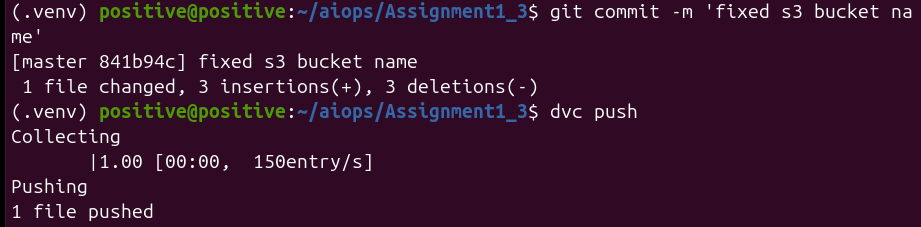

# 3.2 Simulate Data Update and Create V2

### Fetch the Additional Labels

##### (.venv) positive@positive:~/aiops/Assignment1_3$ dvc get https://github.com/iterative/dataset-registry tutorials/versioning/new-labels.zip

##### (.venv) positive@positive:~/aiops/Assignment1_3$ unzip new-labels.zip

Archive: new-labels.zip

inflating: data/train/dogs/dog.775.jpg
inflating: data/train/dogs/dog.761.jpg
...

### Verify the Data Update

##### (.venv) positive@positive:~/aiops/Assignment1_3$ dvc diff

Added:

data/train/cats/cat.1000.jpg
data/train/cats/cat.501.jpg
data/train/cats/cat.502.jpg
...

Modified:

data/

files summary: 1000 added

The lecture likewise uses `dvc diff` to confirm that the tracked data has changed before creating the next DVC version.

### Verify Updated Dataset Size

##### (.venv) positive@positive:~/aiops/Assignment1_3$ find data -type f | wc -l

2800

### Update the CSV

##### (.venv) positive@positive:~/aiops/Assignment1_3$ wc -l filenames.csv

1801 filenames.csv

##### (.venv) positive@positive:~/aiops/Assignment1_3$ echo 'filename' > filenames.csv

##### (.venv) positive@positive:~/aiops/Assignment1_3$ find data -type f | sort >> filenames.csv

##### (.venv) positive@positive:~/aiops/Assignment1_3$ wc -l filenames.csv

2801 filenames.csv

This confirms **2800 filename rows + 1 header**.

### Check That DVC Detects the CSV Change

##### (.venv) positive@positive:~/aiops/Assignment1_3$ dvc status

filenames.csv.dvc:
    changed outs:
        modified: filenames.csv

### Create V2

##### (.venv) positive@positive:~/aiops/Assignment1_3$ dvc add filenames.csv

100% Adding...|█████████████████████████████████████████████████████████████████████████|1/1 [...]

To track the changes with Git, run:

`git add filenames.csv.dvc`

##### (.venv) positive@positive:~/aiops/Assignment1_3$ git add filenames.csv.dvc

##### (.venv) positive@positive:~/aiops/Assignment1_3$ git commit -m 'update filenames to version 2'

[master 44c3d11] update filenames to version 2
1 file changed, 2 insertions(+), 2 deletions(-)

##### (.venv) positive@positive:~/aiops/Assignment1_3$ git tag -a v2.0 -m 'data version 2 with 2800 filenames'

### Push V2

##### (.venv) positive@positive:~/aiops/Assignment1_3$ dvc push

Collecting |1.00 [00:00, 224 entry/s]
Pushing


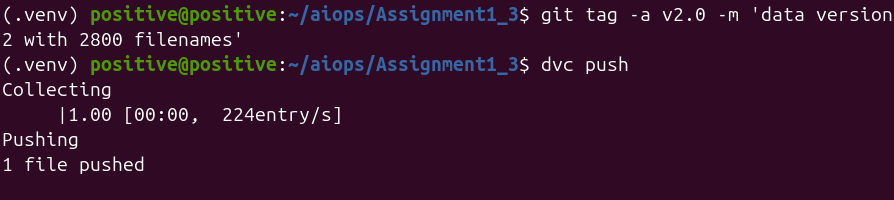

### Question 3.3

##### (.venv) positive@positive:~/aiops/Assignment1_3$ git checkout v1.0

Note: switching to 'v1.0'.

You are in 'detached HEAD' state. You can look around, make experimental changes and commit them, and you can discard any commits you make in this state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may do so (now or later) by using `-c` with the switch command. Example:

#### git switch -c <new-branch-name>

Or undo this operation with:

#### git switch -

Turn off this advice by setting config variable `advice.detachedHead` to `false`.

HEAD is now at `ee56a44` first version of filenames.

#### (.venv) positive@positive:~/aiops/Assignment1_3$ dvc checkout

Building workspace index                               |1.00 [00:00, 60.1 entry/s]
Comparing indexes                                      |2.00 [00:00, 897 entry/s]
Applying changes                                       |1.00 [00:00, 297 file/s]
M       filenames.csv

#### (.venv) positive@positive:~/aiops/Assignment1_3$ wc -l filenames.csv

1801 filenames.csv
